In [137]:
import pandas as pd
import numpy as np

import sys
import warnings
import itertools
warnings.filterwarnings("ignore")

In [138]:
from google.colab import drive
drive.mount('/content/drive')

path="/content/drive/MyDrive/PDSBA/PDS/FRA/Part B/MarketRiskDataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [139]:
df = pd.read_csv(path)

In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 314 non-null    object
 1   Infosys              314 non-null    int64 
 2   Indian Hotel         314 non-null    int64 
 3   Mahindra & Mahindra  314 non-null    int64 
 4   Axis Bank            314 non-null    int64 
 5   SAIL                 314 non-null    int64 
 6   Shree Cement         314 non-null    int64 
 7   Sun Pharma           314 non-null    int64 
 8   Jindal Steel         314 non-null    int64 
 9   Idea Vodafone        314 non-null    int64 
 10  Jet Airways          314 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 27.1+ KB


In [141]:
df.shape

(314, 11)

In [142]:
df.describe()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
count,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000,314.000000
mean,511.340764,114.560510,636.678344,540.742038,59.095541,14806.410828,633.468153,147.627389,53.713376,372.659236
std,135.952051,22.509732,102.879975,115.835569,15.810493,4288.275085,171.855893,65.879195,31.248985,202.262668
min,234.000000,64.000000,284.000000,263.000000,21.000000,5543.000000,338.000000,53.000000,3.000000,14.000000
25%,424.000000,96.000000,572.000000,470.500000,47.000000,10952.250000,478.500000,88.250000,25.250000,243.250000
50%,466.500000,115.000000,625.000000,528.000000,57.000000,16018.500000,614.000000,142.500000,53.000000,376.000000
75%,630.750000,134.000000,678.000000,605.250000,71.750000,17773.250000,785.000000,182.750000,82.000000,534.000000
max,810.000000,157.000000,956.000000,808.000000,104.000000,24806.000000,1089.000000,338.000000,117.000000,871.000000


In [143]:
df.head()

,Date,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
0,31-03-2014,264,69,455,263,68,5543,555,298,83,278
1,07-04-2014,257,68,458,276,70,5728,610,279,84,303
2,14-04-2014,254,68,454,270,68,5649,607,279,83,280
3,21-04-2014,253,68,488,283,68,5692,604,274,83,282
4,28-04-2014,256,65,482,282,63,5582,611,238,79,243


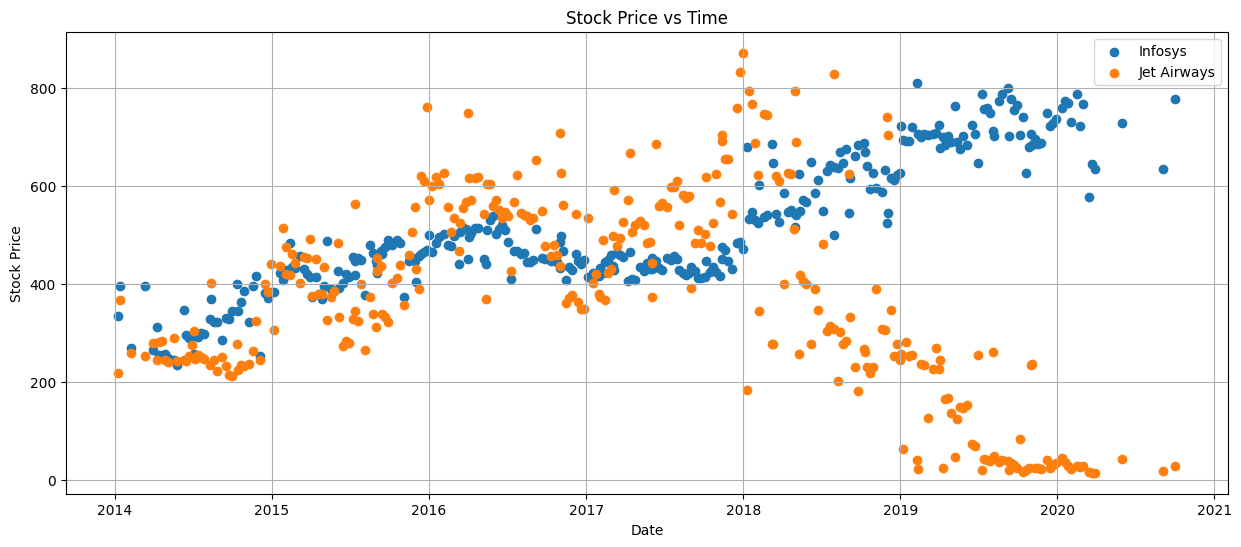

In [144]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

df_returns = df.drop(columns=['Date']).pct_change() * 100

plt.figure(figsize=(15, 6))
plt.scatter(df['Date'], df['Infosys'], label='Infosys')
plt.scatter(df['Date'], df['Jet Airways'], label='Jet Airways')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Stock Price vs Time')
plt.legend()
plt.grid(True)
plt.show()

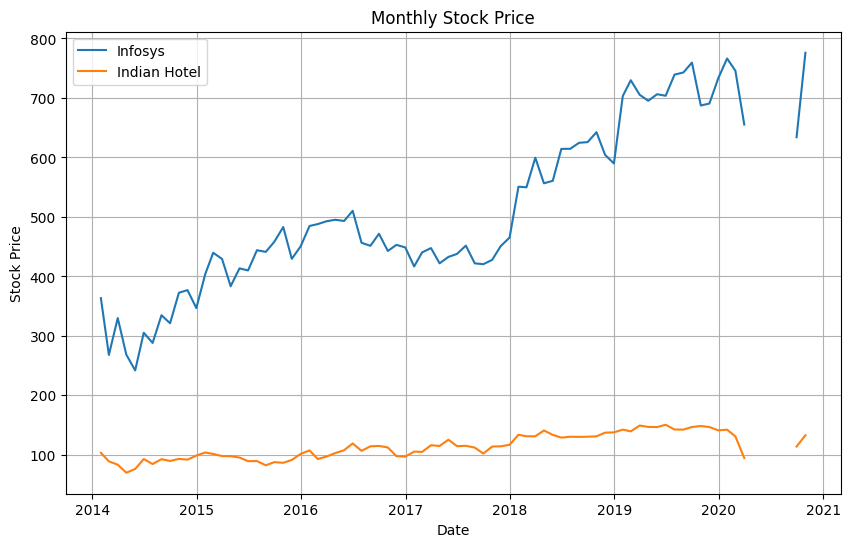

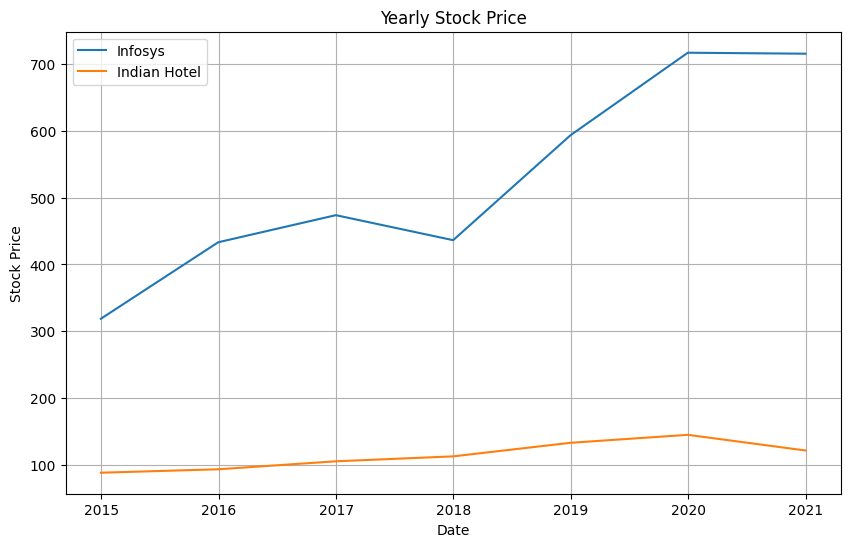

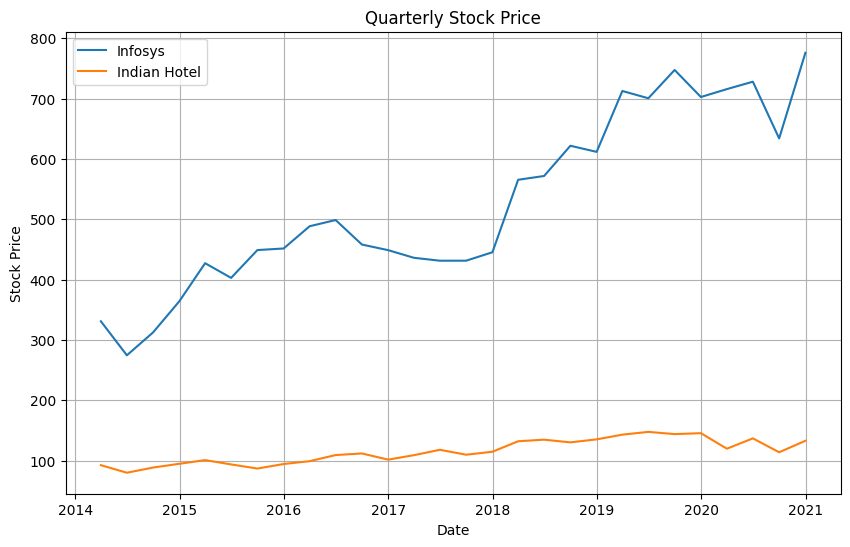

In [145]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

df_monthly = df.resample('M').mean()
df_yearly = df.resample('Y').mean()
df_quarterly = df.resample('Q').mean()

plt.figure(figsize=(10, 6))
plt.plot(df_monthly.index, df_monthly['Infosys'], label='Infosys')
plt.plot(df_monthly.index, df_monthly['Indian Hotel'], label='Indian Hotel')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Monthly Stock Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_yearly.index, df_yearly['Infosys'], label='Infosys')
plt.plot(df_yearly.index, df_yearly['Indian Hotel'], label='Indian Hotel')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Yearly Stock Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(df_quarterly.index, df_quarterly['Infosys'], label='Infosys')
plt.plot(df_quarterly.index, df_quarterly['Indian Hotel'], label='Indian Hotel')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Quarterly Stock Price')
plt.legend()
plt.grid(True)
plt.show()



In [108]:
df.columns




Index(['Infosys', 'Indian Hotel', 'Mahindra & Mahindra', 'Axis Bank', 'SAIL',
       'Shree Cement', 'Sun Pharma', 'Jindal Steel', 'Idea Vodafone',
       'Jet Airways'],
      dtype='object')

             Infosys  Indian Hotel  Mahindra & Mahindra  Axis Bank      SAIL  \
Date                                                                           
2014-03-31       NaN           NaN                  NaN        NaN       NaN   
2014-07-04 -0.026873     -0.014599             0.006572   0.048247  0.028988   
2014-04-14 -0.011742      0.000000            -0.008772  -0.021979 -0.028988   
2014-04-21 -0.003945      0.000000             0.072218   0.047025  0.000000   
2014-04-28  0.011788     -0.045120            -0.012371  -0.003540 -0.076373   
...              ...           ...                  ...        ...       ...   
2020-02-03  0.009649     -0.110348             0.030305  -0.057580 -0.087011   
2020-09-03 -0.139625     -0.051293            -0.093819  -0.145324 -0.095310   
2020-03-16 -0.094207     -0.236389            -0.285343  -0.284757 -0.105361   
2020-03-23  0.109856     -0.182322            -0.091269  -0.173019 -0.251314   
2020-03-30 -0.017228      0.000000      

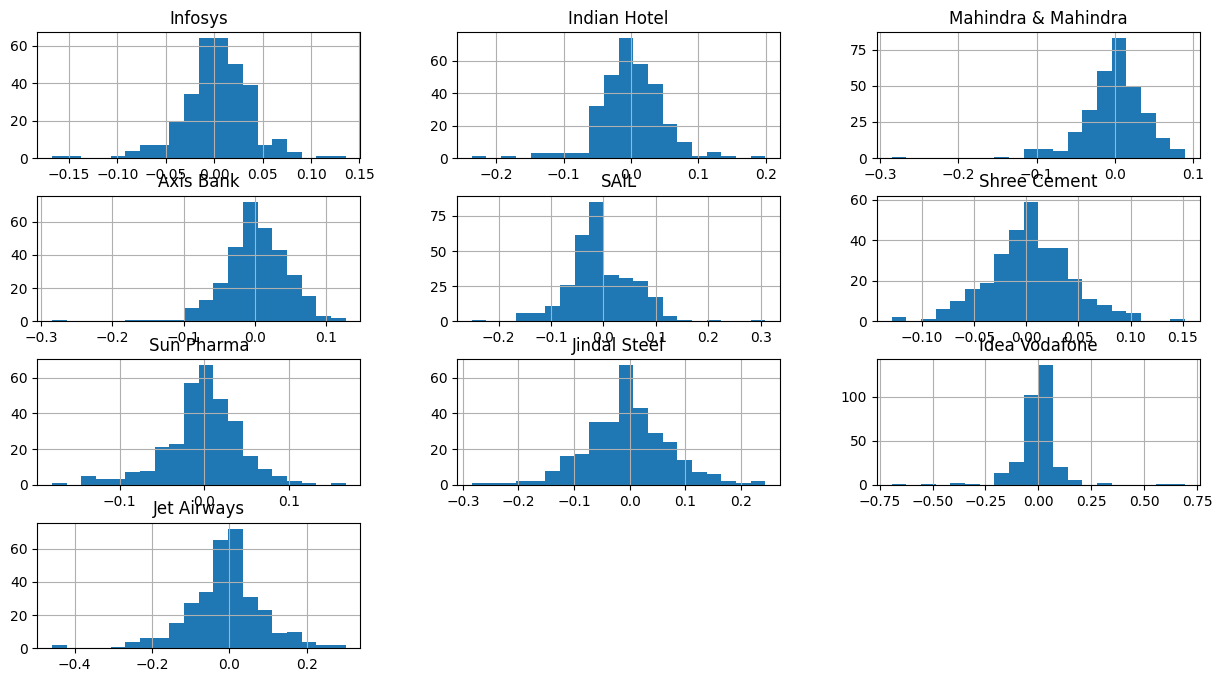

In [150]:
import pandas as pd
import numpy as np

stock_returns = np.log(df).diff()

print(stock_returns)

mean_returns = stock_returns.mean()
std_returns = stock_returns.std()

print("\nMean Returns:")
print(mean_returns)
print("\nStandard Deviation of Returns:")
print(std_returns)

stock_returns.hist(bins=20, figsize=(15, 8))
plt.title('Histogram of Stock Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()


In [129]:
stock_returns.shape

(314, 10)

In [149]:
stock_returns.describe()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
count,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000
mean,0.002794,0.000266,-0.001506,0.001167,-0.003463,0.003681,-0.001455,-0.004123,-0.010608,-0.009548
std,0.035070,0.047131,0.040169,0.045828,0.062188,0.039917,0.045033,0.075108,0.104315,0.097972
min,-0.167300,-0.236389,-0.285343,-0.284757,-0.251314,-0.129215,-0.179855,-0.283768,-0.693147,-0.458575
25%,-0.014514,-0.023530,-0.020884,-0.022473,-0.040822,-0.019546,-0.020699,-0.049700,-0.045120,-0.052644
50%,0.004376,0.000000,0.001526,0.001614,0.000000,0.003173,0.001530,0.000000,0.000000,-0.005780
75%,0.024553,0.027909,0.019894,0.028522,0.032790,0.029873,0.023257,0.037179,0.024391,0.036368
max,0.135666,0.199333,0.089407,0.127461,0.309005,0.152329,0.166604,0.243978,0.693147,0.300249


In [130]:
stock_returns.head()

,Infosys,Indian Hotel,Mahindra & Mahindra,Axis Bank,SAIL,Shree Cement,Sun Pharma,Jindal Steel,Idea Vodafone,Jet Airways
Date,,,,,,,,,,
2014-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-07-04,-0.026873,-0.014599,0.006572,0.048247,0.028988,0.032831,0.094491,-0.065882,0.011976,0.086112
2014-04-14,-0.011742,0.000000,-0.008772,-0.021979,-0.028988,-0.013888,-0.004930,0.000000,-0.011976,-0.078943
2014-04-21,-0.003945,0.000000,0.072218,0.047025,0.000000,0.007583,-0.004955,-0.018084,0.000000,0.007117
2014-04-28,0.011788,-0.045120,-0.012371,-0.003540,-0.076373,-0.019515,0.011523,-0.140857,-0.049393,-0.148846


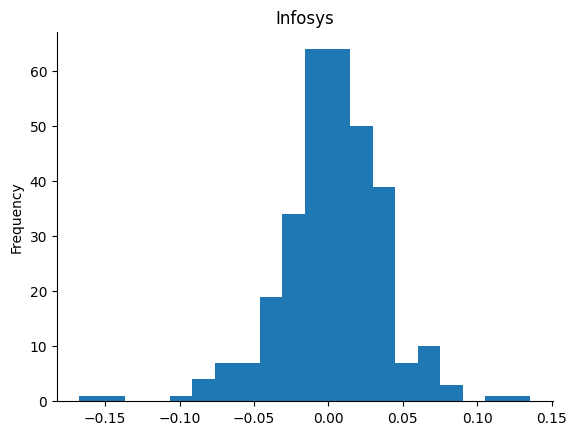

In [147]:
# @title Infosys

from matplotlib import pyplot as plt
stock_returns['Infosys'].plot(kind='hist', bins=20, title='Infosys')
plt.gca().spines[['top', 'right',]].set_visible(False)

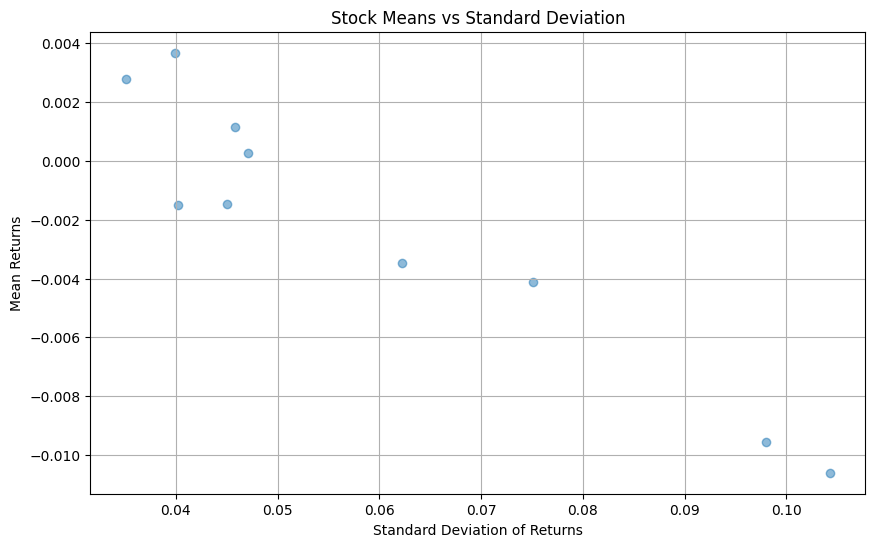

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(std_returns, mean_returns, alpha=0.5)
plt.xlabel('Standard Deviation of Returns')
plt.ylabel('Mean Returns')
plt.title('Stock Means vs Standard Deviation')
plt.grid(True)
plt.show()


In [151]:
df2 = pd.DataFrame({'Average':mean_returns, 'Volatility': std_returns})
df2

,Average,Volatility
Infosys,0.002794,0.035070
Indian Hotel,0.000266,0.047131
Mahindra & Mahindra,-0.001506,0.040169
Axis Bank,0.001167,0.045828
SAIL,-0.003463,0.062188
Shree Cement,0.003681,0.039917
Sun Pharma,-0.001455,0.045033
Jindal Steel,-0.004123,0.075108
Idea Vodafone,-0.010608,0.104315
Jet Airways,-0.009548,0.097972


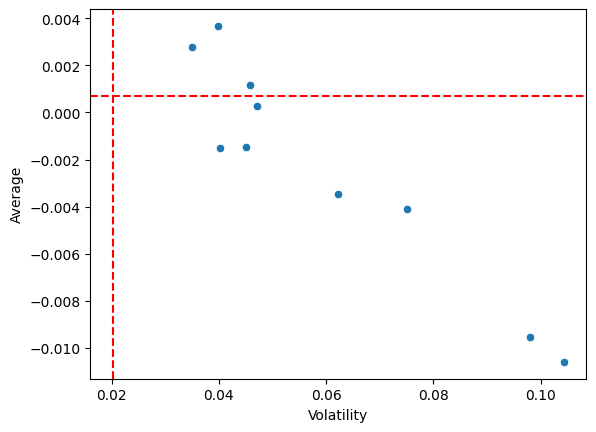

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plot = sns.scatterplot(x=df2['Volatility'], y=df2['Average'])

plot.axvline(x=0.020257, linestyle='--', color="red")
plot.axhline(y=0.000683, linestyle='--', color="red")

plt.show()
